# Lecture 2 - (02/06/2026)

### Today's Topics:

- Lambda Functions
- Data Science Lifecycle
- Case Study: Why is my bus always late?
- Data Scope, Big Data, Accuracy
- Statistics Recap
- Sampling Methods

## Lambda functions
- Lambda expressions are “small anonymous functions”
- Mainly used for small and temporary tasks.
- Very common for `apply()` (and `map()` & `reduce()`).
- They can be stored as a variable and used as a function

In [ ]:
f = lambda x : x**2
f(4), f(6), f(8), f(10)

(16, 36, 64, 100)

In [ ]:
pairs = [('Alice', 94), ('Bob', 87), ('Charlie', 78), ('David', 88), ('Emily', 83)]
pairs.sort(key = lambda pair : pair[1])
pairs

[('Charlie', 78), ('Emily', 83), ('Bob', 87), ('David', 88), ('Alice', 94)]

Example: create a new column that is true a pokemon has two types

In [ ]:
import pandas as pd
df = pd.read_csv("https://gist.githubusercontent.com/armgilles/194bcff35001e7eb53a2a8b441e8b2c6/raw/92200bc0a673d5ce2110aaad4544ed6c4010f687/pokemon.csv")
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [ ]:
df = df.assign(two_type_boolean = lambda row : (row["Type 2"].notna()))
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,two_type_boolean
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,True
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,True
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,True
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,True
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,False


## Data Science Lifecycle

![image](https://ds100.org/course-notes-su23/intro_lec/images/data_life_cycle.PNG)

1. Ask a question
    -  What do we want to know?
    -  What problems are we trying to solve? 
    -  What are the hypotheses we want to test? 
    -  What are the metrics for our success? 

2. Obtain data
    - What data do we have and what data do we need? 
    - How will we sample more data? 
    - Is our data representative of the population we want to study? 

3. Understand the Data
    - How is our data organized and what does it contain? 
    - Do we have relevant data? 
    - What are the biases, anomalies, or other issues with the data? 
    - How do we transform the data to enable effective analysis? 

4. Understand the world
    - What does the data say about the world? 
    - Does it answer our questions or accurately solve the problem? 
    - How robust are our conclusions and can we trust the predictions? 

The data science lifecycle is meant to be a set of general guidelines rather than a hard list of requirements.

## Case Study:  Why is my Bus Always Late?

You arrive at the bus stop, ready to catch your bus: a line that advertises arrivals every 10 minutes. You glance at your watch and note the time... and when the bus finally comes 11 minutes later, you wonder why you always seem to be so unlucky.

Naïvely, you might expect that if buses are coming every 10 minutes and you arrive at a random time, your average wait would be something like 5 minutes. In reality, though, buses do not arrive exactly on schedule, and so you might wait longer. It turns out that under some reasonable assumptions, you can reach a startling conclusion:

When waiting for a bus that comes on average every 10 minutes, your average waiting time will be 10 minutes.

In [ ]:
import pandas as pd
url = "https://gist.githubusercontent.com/jakevdp/82409002fcc5142a2add0168c274a869/raw/1bbabf78333306dbc45b9f33662500957b2b6dc3/arrival_times.csv"
df = pd.read_csv(url)
df = df.dropna(axis=0, how='any')
df.head()

,OPD_DATE,VEHICLE_ID,RTE,DIR,TRIP_ID,STOP_ID,STOP_NAME,SCH_STOP_TM,ACT_STOP_TM
0,2016-03-26,6201,673,S,30908177,431,3RD AVE & PIKE ST (431),01:11:57,01:13:19
1,2016-03-26,6201,673,S,30908033,431,3RD AVE & PIKE ST (431),23:19:57,23:16:13
2,2016-03-26,6201,673,S,30908028,431,3RD AVE & PIKE ST (431),21:19:57,21:18:46
3,2016-03-26,6201,673,S,30908019,431,3RD AVE & PIKE ST (431),19:04:57,19:01:49
4,2016-03-26,6201,673,S,30908252,431,3RD AVE & PIKE ST (431),16:42:57,16:42:39


Question: Blog focuses on Seattle. 
- Narrow focus to: 1 bus stop over 2 month time frame

Data Acquisition and Cleaning: 
- Let’s clean up the data a bit first before going on.

Exploratory Data Analysis:
- What is in the CSV?
- Does the data make sense

In [ ]:
''' cleaning (you can ignore this!) '''
import numpy as np

# combine date and time into a single timestamp
df['scheduled'] = pd.to_datetime(df['OPD_DATE'] + ' ' + df['SCH_STOP_TM'])
df['actual'] = pd.to_datetime(df['OPD_DATE'] + ' ' + df['ACT_STOP_TM'])

# if scheduled & actual span midnight, then the actual day needs to be adjusted
minute = np.timedelta64(1, 'm')
hour = 60 * minute
diff_hrs = (df['actual'] - df['scheduled']) / hour
df.loc[diff_hrs > 20, 'actual'] -= 24 * hour
df.loc[diff_hrs < -20, 'actual'] += 24 * hour
df['minutes_late'] = (df['actual'] - df['scheduled']) / minute

# map internal route codes to external route letters
df['route'] = df['RTE'].replace({673: 'C', 674: 'D', 675: 'E'}).astype('category')
df['direction'] = df['DIR'].replace({'N': 'northbound', 'S': 'southbound'}).astype('category')

# extract useful columns
df = df[['route', 'direction', 'scheduled', 'actual', 'minutes_late']].copy()

df.head()


,route,direction,scheduled,actual,minutes_late
0,C,southbound,2016-03-26 01:11:57,2016-03-26 01:13:19,1.366667
1,C,southbound,2016-03-26 23:19:57,2016-03-26 23:16:13,-3.733333
2,C,southbound,2016-03-26 21:19:57,2016-03-26 21:18:46,-1.183333
3,C,southbound,2016-03-26 19:04:57,2016-03-26 19:01:49,-3.133333
4,C,southbound,2016-03-26 16:42:57,2016-03-26 16:42:39,-0.300000


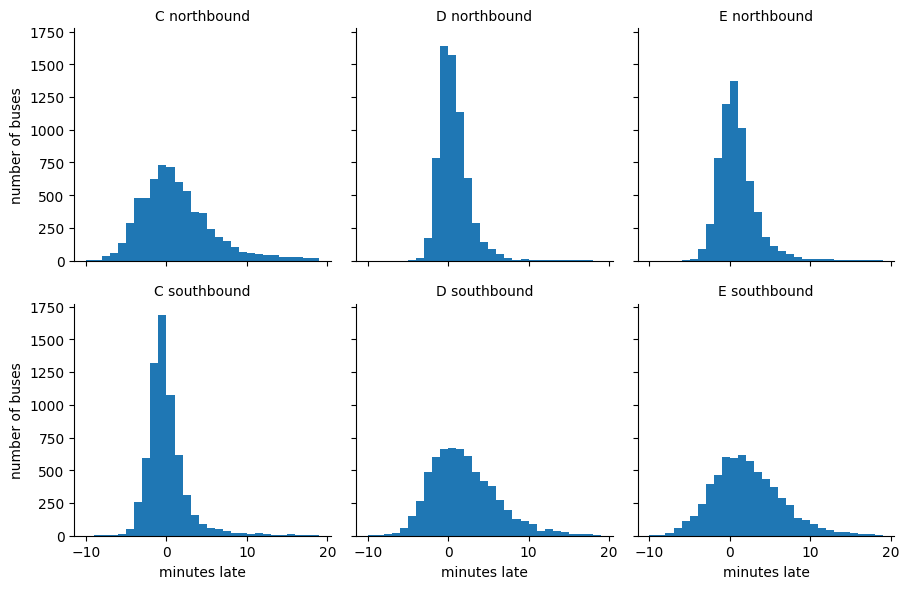

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df, row="direction", col="route")
g.map(plt.hist, "minutes_late", bins=np.arange(-10, 20))
g.set_titles('{col_name} {row_name}')
g.set_axis_labels('minutes late', 'number of buses');

## Data Scope

- How can we draw conclusions about large populations using small samples?
- E.g., pollsters sample small numbers of voters to predict election results.
- Famous polling failures: 
    - Literary Digest predicted Roosevelt would lose in 1936 (based on sample of those with telephone & car registration)  
    - Gallup Poll used quota sampling in 1948 and predicted Dewey winning.
- How can we do better?

#### Generalizing from Data: Sampling Scenarios

- Population: The set of all people
- Sampling frame: The set of all possible units that can be drawn into a sample
- Sample: a subset of the sampling frame

![image](../attachments/ds100_sample_pop.png)

### Bias

- Coverage bias: access frame does not include everyone in the target population.
    - Ex:  A phone survey cannot reach those without a phone.
- Selection bias: certain items selected more than should.
    - Ex:  a convenience sample chooses the units most easily available.
- Non-response bias: unit and item.  Unwilling to participate at all or for given item.
- Measurement bias: happens when an instrument systematically misses the target in one direction.
    - Ex:  low humidity can give us incorrectly high measurements of air pollution. 

### Variation

Variation is also called Precision in Computer Science fields (i.e. ML, AI, Numerical Methods)

- Sampling variation: results from using chance to select a sample.
    - Can (often) compute the chance a particular elements is selected.
- Assignment variation: occurs when we assign units at random to treatment groups.
    - Can (often) compute the chance of a particular group assignment.
- Measurement error: for an instrument results from the measurement process.
    - Assuming no drift or bias, taking multiple measurements on the same object will give random variations that are centered on the truth.

## Statistics Recap

### Expectation and Variance

![image](../attachments/seeingTheory.png)

[Seeing Theory by Brown University](https://seeing-theory.brown.edu/)

### Correlation Coefficients

Roughly: measuring interdependence of two variables.

Pearson's R Correlation Coefficient:
- Ranges from $1$ (positively correlated) to $-1$ (negatively correlated)

$$ r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}
                    {\sqrt{(\sum_i (x_i - \bar{x})^2)(\sum_i (y_i - \bar{y})^2)}}
                    = \frac{cov(x,y)}{\sigma_x \sigma_y} $$

In [8]:
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df[['total_bill', 'tip', 'size']].corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


This table is called the correlation matrix, the closer it is to 1, the more strongly variable x and y are related. 

Correlation does not imply causation!!!

In [13]:
import numpy as np

n = 365 
temperature = np.random.normal(75, 10, n)

# generate dummy data

ice_cream_sales = 200 + 3 * temperature + np.random.normal(0, 20, n)
crime_rate = 50 + 2 * temperature + np.random.normal(0, 15, n)

df = pd.DataFrame({
    "temperature": temperature,
    "ice_cream_sales": ice_cream_sales,
    "crime_rate": crime_rate
})

df[['ice_cream_sales', 'crime_rate']].corr()

,ice_cream_sales,crime_rate
ice_cream_sales,1.00000,0.60959
crime_rate,0.60959,1.00000


Claim: Higher ice cream sales cause more crime.

Reality:
- Temperature is a **confounding** variable
- Hot days -> more ice cream sales
- Hot days -> more people outside -> more crime

![image](https://www.simplypsychology.org/wp-content/uploads/correlation-coefficient.jpg)


[Lies, damned lies, and statistics](https://en.wikipedia.org/wiki/Lies,_damned_lies,_and_statistics)

![image](../attachments/ubc_guess_correlation.png)

[Let's try to guess the correlation](https://shiney.zoology.ubc.ca/whitlock/Guessing_correlation/)

### Summary Statistics

![Normal](../attachments/ds8_normal_curve_ch14.png)

$$\phi(z) = \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}z^2}, -\infty < z < \infty$$

- The curve is symmetric about 0 with its mean and median both 0.
- Pandas:  x.mean() and x.median()
- If a variable has this distribution, its SD is 1.
- Pandas:  x.std()

## Linear Modeling

We can score each line with how close the actual and predicted y-values are, using RMSE for the loss function.

The line with the best score is determined as the regression line.

We can visualize this process [here](https://setosa.io/ev/ordinary-least-squares-regression/)

Our goal in linear regression is to seek the line $y=mx+b$ that minimizes the least square errors

That is to say, the line that minimizes the mean of the MSE(mean squared errors) for all lines.

When x and y are in standard units, regression line is:

$$ y = r*x + 0$$

Let's try a [game](https://regression.historyofdatascience.com/) (make sure to record your scores)!

Modeling should generally consist of three main steps

- Select a model (in our case linear regression)
- Select a loss function (in our case RMSE)
- Minimize the loss function

We also need to prep our data for prediction, adding in those steps:

- Split your data into pieces for training & validation.
- Select a model (in our case linear regression)
- Select a loss function (in our case RMSE)
- Minimize the loss function, using the training data
- Validate your model with the reserved test data